# PREPROCESSING

In [32]:
import pandas as pd
import os

project_name = "sjafrie_sjamsoeddin"
file_name = f"{project_name}_articles.csv"

# =========================
# SETUP FOLDER
# =========================
base_folder = f"../../result/{project_name}/news"
output_folder = f"{base_folder}/preprocessing/"
os.makedirs(output_folder, exist_ok=True)

data = pd.read_csv(f"{base_folder}/{file_name}")

# =========================
# NORMALISASI WAKTU
# published_at: Fri Jan 09 01:33:24 +0700 2026
# =========================
data['published_at'] = pd.to_datetime(
    data['published_at'],
    format='%a %b %d %H:%M:%S %z %Y',
    errors='coerce'
).dt.tz_convert('Asia/Jakarta')

# =========================
# BUAT TANGGAL & WAKTU
# =========================
if 'tanggal' not in data.columns or 'waktu' not in data.columns:
    data['tanggal'] = data['published_at'].dt.strftime('%Y-%m-%d')
    data['waktu']   = data['published_at'].dt.strftime('%H:%M:%S')

# =========================
# FORMAT published_at (konsisten dg data X)
# =========================
data['published_at'] = data['published_at'].dt.strftime(
    '%a %b %d %H:%M:%S %z %Y'
)

# =========================
# SELECT KOLOM FINAL
# =========================
df = pd.DataFrame(data[[
    'article_id',
    'published_at', 'tanggal', 'waktu',
    'media', 'author',
    'title', 'tags',
    'media_location', 'event_location',
    'featured_image',
    'url',
    'content'
]])

# =========================
# DEDUPLIKASI (media + article_id / url)
# =========================
seen = set()
rows = []

for _, r in df.iterrows():
    media = r.get("media", "")
    article_id = r.get("article_id")
    url = r.get("url", "")

    # prioritas article_id
    if pd.notna(article_id) and str(article_id).strip() != "-":
        key = (media, "id", str(article_id))
    else:
        key = (media, "url", str(url))

    if key in seen:
        continue

    seen.add(key)
    rows.append(r)

df = pd.DataFrame(rows)

# =========================
# FILTER KONTEN TIDAK VALID
# =========================
# df = df[
#     df['article_id'].notna() &
#     (df['article_id'].str.strip() != "") &
#     (df['article_id'].str.strip() != "-")
# ]
df = df[
    df['content'].notna() &
    (df['content'].str.strip() != "") &
    (df['content'].str.strip() != "-")
]

# =========================
# SIMPAN
# =========================
out_path = f"{output_folder}/prep_{file_name}"
df.to_csv(out_path, index=False)
print(f"Saved to: {out_path}")

# =========================
# OUTPUT CEK
# =========================
df.info()
df.head()

Saved to: ../../result/sjafrie_sjamsoeddin/news/preprocessing//prep_sjafrie_sjamsoeddin_articles.csv
<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 0 to 90
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   article_id      90 non-null     object
 1   published_at    90 non-null     object
 2   tanggal         90 non-null     object
 3   waktu           90 non-null     object
 4   media           90 non-null     object
 5   author          90 non-null     object
 6   title           90 non-null     object
 7   tags            90 non-null     object
 8   media_location  90 non-null     object
 9   event_location  90 non-null     object
 10  featured_image  90 non-null     object
 11  url             90 non-null     object
 12  content         90 non-null     object
dtypes: object(13)
memory usage: 9.8+ KB


,article_id,published_at,tanggal,waktu,media,author,title,tags,media_location,event_location,featured_image,url,content
0,1672233,Sun Feb 01 12:00:37 +0700 2026,2026-02-01,12:00:37,ekbis.sindonews.com,Tangguh Yudha Ramadhan,Menhan Sjafrie Sebut Prabowo Bakal Ganti Direk...,#menhan;#sjafrie sjamsoeddin;#perombakan direk...,Jakarta,Jakarta,https://pict.sindonews.net/dyn/850/pena/news/2...,https://ekbis.sindonews.com/read/1672233/34/me...,CEO Danantara Indonesia yang juga Menteri Inve...
1,412009,Sun Feb 01 04:34:55 +0700 2026,2026-02-01,04:34:55,www.tvonenews.com,Bajo Winarno,"Usai Gonjang Ganjing di Sektor Jasa Keuangan, ...",#sjafrie-sjamsoeddin;#bank-himbara;#prabowo-su...,Jakarta,Jakarta,https://thumbs.tvonenews.com/thumbnail/2026/02...,https://www.tvonenews.com/ekonomi/412009-usai-...,Presiden Prabowo Subianto disebut Menteri Pert...
2,09b33d5b6134c6e63e1c4a5641ff06f7d6d133d2,Sun Feb 01 02:32:00 +0700 2026,2026-02-01,02:32:00,jpnn.com,M. Fathra Nazrul Islam,Menhan Sjafrie: 4.000 ASN di Jakarta Bakal Jad...,#Komcad;#ASN;#Kementerian;#Sjafrie Sjamsoeddin...,Jakarta,Indonesia,https://cloud.jpnn.com/photo/arsip/normal/2026...,https://jpnn.com/news/menhan-sjafrie-4000-asn-...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...
3,7785294,Sat Jan 31 23:02:42 +0700 2026,2026-01-31,23:02:42,www.tribunnews.com,Reza Deni,Prabowo Gelar Pertemuan Rahasia Malam Hari den...,#Prabowo Subianto;#Sjafrie Sjamsoeddin;#Hambal...,Jakarta,Bogor,https://asset.tribunnews.com/E-GDsMr5altFRRdx4...,https://www.tribunnews.com/nasional/7785294/pr...,"Di tengah suasana politik yang dinamis, Presid..."
4,26k0vt3zsme,Sat Jan 31 21:10:49 +0700 2026,2026-01-31,21:10:49,kumparan.com,M Lutfan D,Menhan Sjafrie Melayat ke Rumah Duka Wagub Sul...,#News;#Sjafrie Sjamsoeddin;#Menhan;#Sulbar,Jakarta,Indonesia,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/menhan-sjafr...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...


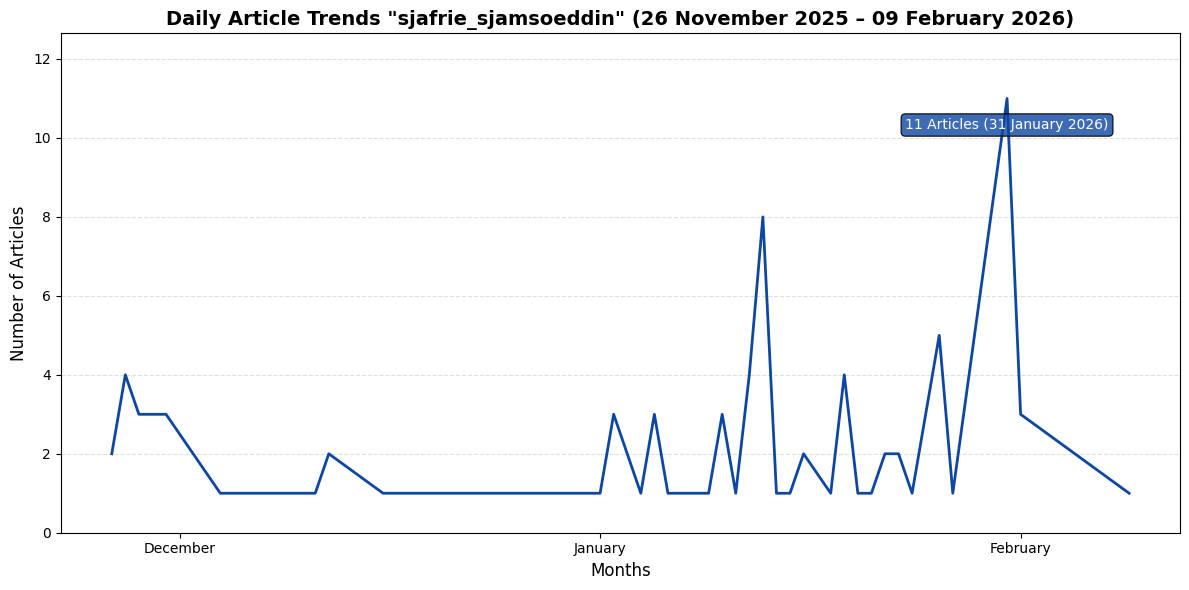

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# Hitung jumlah tweet per tanggal
daily_counts = df_filtered.groupby("tanggal").size().sort_index()

# Hitung durasi total hari
total_days = (daily_counts.index.max() - daily_counts.index.min()).days

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts, color="#0D47A1", linewidth=2,)

# ======== Format X-axis adaptif ========
ax = plt.gca()
xlabel=""
if total_days < 14:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    xlabel="Days"
elif total_days < 31:
# else:
    week_labels = []
    current_month = None
    week_counter = 1
    last_label_date = None
    for date in daily_counts.index:
        if current_month != date.strftime("%b"):
            current_month = date.strftime("%b")
            week_counter = 1
        if last_label_date is None or (date - last_label_date).days >= 7:
            week_labels.append(f"{current_month} W{week_counter}")
            week_counter += 1
            last_label_date = date
        else:
            week_labels.append("")
    plt.xticks(daily_counts.index, week_labels, rotation=0, ha="center")
    xlabel="Weeks"
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    xlabel="Months"
    

# ======== Temukan puncak data ========
max_value = daily_counts.max()
max_dates = daily_counts[daily_counts == max_value].index

if len(max_dates) > 1:
    start_peak = max_dates.min()
    end_peak = max_dates.max()
    label_text = f"{max_value:,} Articles ({start_peak.strftime('%d %B')} & {end_peak.strftime('%d %B')})"
    peak_date = start_peak + (end_peak - start_peak) / 2
else:
    peak_date = max_dates[0]
    label_text = f"{max_value:,} Articles ({peak_date.strftime('%d %B %Y')})"

# ======== Atur batas atas Y agar label tidak keluar ========
y_margin = max_value * 0.15
plt.ylim(0, max_value + y_margin)

# ======== Tambahkan label di dalam frame ========
plt.text(
    peak_date, max_value - (y_margin * 0.3),
    label_text,
    ha="center", va="top",
    fontsize=10, color="white",
    bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
)

# ======== Styling ========
plt.title(f"Daily Article Trends \"{project_name}\" ({start_date.strftime('%d %B %Y')} – {end_date.strftime('%d %B %Y')})", fontsize=14, fontweight="bold")
plt.xlabel(xlabel, fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# ======== Save Figure ========
plt.savefig(f"{output_folder}/{project_name}_trend_daily.png", dpi=300, bbox_inches="tight")

plt.show()


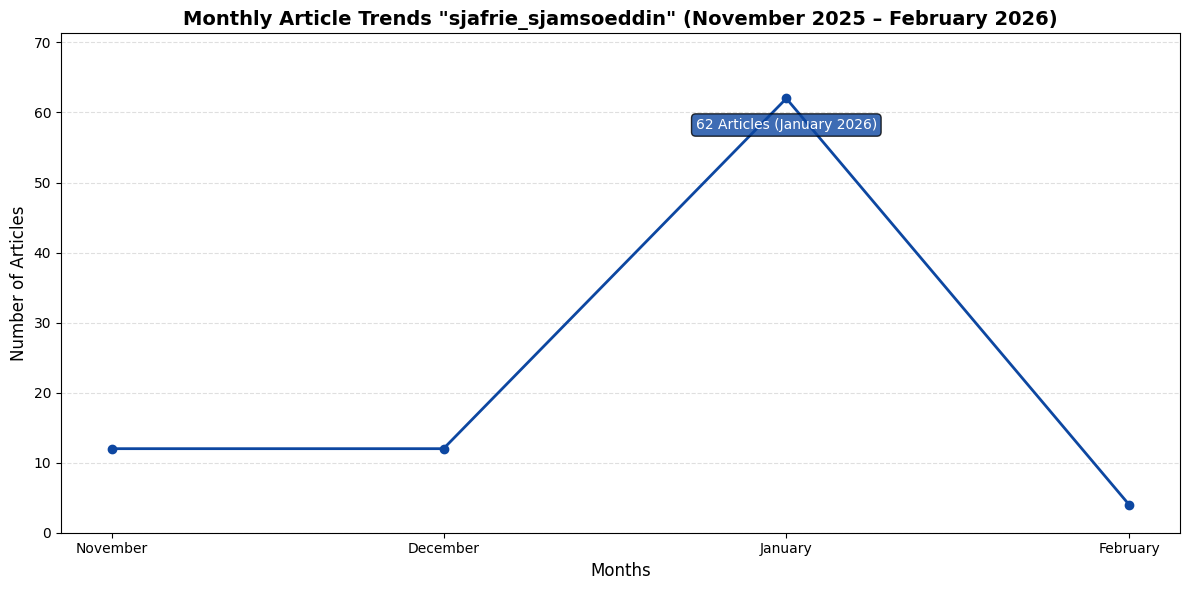

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# ======== Hitung jumlah tweet per bulan ========
df_filtered["bulan"] = df_filtered["tanggal"].dt.to_period("M").dt.to_timestamp()
monthly_counts = df_filtered.groupby("bulan").size().sort_index()

# ======== Cek jika data kosong ========
if monthly_counts.empty:
    print("⚠️ Tidak ada data yang bisa ditampilkan dalam rentang waktu ini.")
else:
    # ======== Plot ========
    plt.figure(figsize=(12,6))
    plt.plot(monthly_counts.index, monthly_counts, color="#0D47A1", linewidth=2, marker="o")

    # ======== Format X-axis ========
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=0, ha="center")

    # ======== Temukan puncak data ========
    max_value = monthly_counts.max()
    max_months = monthly_counts[monthly_counts == max_value].index

    if len(max_months) > 1:
        start_peak = max_months.min()
        end_peak = max_months.max()
        label_text = f"{max_value:,} Articles ({start_peak.strftime('%B')} – {end_peak.strftime('%B %Y')})"
        peak_date = start_peak + (end_peak - start_peak) / 2
    else:
        peak_date = max_months[0]
        label_text = f"{max_value:,} Articles ({peak_date.strftime('%B %Y')})"

    # ======== Atur batas atas Y agar label tidak keluar ========
    y_margin = max_value * 0.15
    plt.ylim(0, max_value + y_margin)

    # ======== Tambahkan label di dalam frame ========
    plt.text(
        peak_date, max_value - (y_margin * 0.3),
        label_text,
        ha="center", va="top",
        fontsize=10, color="white",
        bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
    )

    # ======== Styling ========
    plt.title(f"Monthly Article Trends \"{project_name}\" ({start_date.strftime('%B %Y')} – {end_date.strftime('%B %Y')})", fontsize=14, fontweight="bold")
    plt.xlabel("Months", fontsize=12)
    plt.ylabel("Number of Articles", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()

    # ======== Save Figure ========
    plt.savefig(f"{output_folder}/{project_name}_trend_monthly.png", dpi=300, bbox_inches="tight")

    plt.show()

# ======== Simpan CSV Bulanan ========
monthly_df = monthly_counts.reset_index()
monthly_df.columns = ["bulan", "jumlah_data"]
monthly_df["bulan"] = monthly_df["bulan"].dt.strftime("%B %Y")
monthly_df.to_csv(f"{output_folder}/{project_name}_trend_monthly.csv", index=False)

In [35]:
# CASE FOLDING
def case_folding(tweet):
  if isinstance(tweet, str):
    lowerCase = tweet.lower()
    return lowerCase

df['case_folding'] = df['content'].apply(case_folding)

df.head(5)

,article_id,published_at,tanggal,waktu,media,author,title,tags,media_location,event_location,featured_image,url,content,case_folding
0,1672233,Sun Feb 01 12:00:37 +0700 2026,2026-02-01,12:00:37,ekbis.sindonews.com,Tangguh Yudha Ramadhan,Menhan Sjafrie Sebut Prabowo Bakal Ganti Direk...,#menhan;#sjafrie sjamsoeddin;#perombakan direk...,Jakarta,Jakarta,https://pict.sindonews.net/dyn/850/pena/news/2...,https://ekbis.sindonews.com/read/1672233/34/me...,CEO Danantara Indonesia yang juga Menteri Inve...,ceo danantara indonesia yang juga menteri inve...
1,412009,Sun Feb 01 04:34:55 +0700 2026,2026-02-01,04:34:55,www.tvonenews.com,Bajo Winarno,"Usai Gonjang Ganjing di Sektor Jasa Keuangan, ...",#sjafrie-sjamsoeddin;#bank-himbara;#prabowo-su...,Jakarta,Jakarta,https://thumbs.tvonenews.com/thumbnail/2026/02...,https://www.tvonenews.com/ekonomi/412009-usai-...,Presiden Prabowo Subianto disebut Menteri Pert...,presiden prabowo subianto disebut menteri pert...
2,09b33d5b6134c6e63e1c4a5641ff06f7d6d133d2,Sun Feb 01 02:32:00 +0700 2026,2026-02-01,02:32:00,jpnn.com,M. Fathra Nazrul Islam,Menhan Sjafrie: 4.000 ASN di Jakarta Bakal Jad...,#Komcad;#ASN;#Kementerian;#Sjafrie Sjamsoeddin...,Jakarta,Indonesia,https://cloud.jpnn.com/photo/arsip/normal/2026...,https://jpnn.com/news/menhan-sjafrie-4000-asn-...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...
3,7785294,Sat Jan 31 23:02:42 +0700 2026,2026-01-31,23:02:42,www.tribunnews.com,Reza Deni,Prabowo Gelar Pertemuan Rahasia Malam Hari den...,#Prabowo Subianto;#Sjafrie Sjamsoeddin;#Hambal...,Jakarta,Bogor,https://asset.tribunnews.com/E-GDsMr5altFRRdx4...,https://www.tribunnews.com/nasional/7785294/pr...,"Di tengah suasana politik yang dinamis, Presid...","di tengah suasana politik yang dinamis, presid..."
4,26k0vt3zsme,Sat Jan 31 21:10:49 +0700 2026,2026-01-31,21:10:49,kumparan.com,M Lutfan D,Menhan Sjafrie Melayat ke Rumah Duka Wagub Sul...,#News;#Sjafrie Sjamsoeddin;#Menhan;#Sulbar,Jakarta,Indonesia,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/menhan-sjafr...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...


In [ ]:
# NORMALIZE
def normalize(text, kamus):
  if isinstance(text, str):
    words = text.split()
    replaced_words = []
    kata_baku = []
    kata_diganti = []
    kata_tidak_baku_hash = []

    for word in words:
      exclude = ['']
      if word in exclude:
        replaced_words.append(word)
        continue
      if word in kamus:
        baku_word = kamus[word]
        replaced_words.append(baku_word)
        kata_baku.append(baku_word)
        kata_diganti.append(word)
        kata_tidak_baku_hash.append(word)
      else:
        replaced_words.append(word)

    replaced_text = " ".join(replaced_words)

  else:
    replaced_text = ""
    kata_baku = []
    kata_diganti = []
    kata_tidak_baku_hash = []

  return replaced_text, kata_baku, kata_diganti, kata_tidak_baku_hash

kamus_kata = pd.read_excel("../kamus_normalize.xlsx")
kamus = dict(zip(kamus_kata['slang'], kamus_kata['formal']))

df['normalize'] = df['case_folding'].apply(lambda x: normalize(x, kamus)[0])

df.head(5)

In [36]:
# CLEANSING
import re

def cleansing(tweet):
  # Remove ASCII (replace non-ASCII characters with '?')
  tweet = tweet.encode('ascii', 'replace').decode('ascii')
  tweet = re.sub(r'[0-9]+', '', tweet) # Remove angka
  tweet = re.sub(r'^rt[\s]+', ' ', tweet) # Remove retweet marker (RT)
  tweet = re.sub(r'@[^\s]+', ' ', tweet)  # Remove Mention
  tweet = re.sub(r'#[^\s]+', ' ', tweet)  # Remove tagar
  tweet = re.sub(r'http\S+|www\.\S+', '', tweet)  # Remove URL
  emoji_pattern = re.compile(
      "["
      "\U0001F600-\U0001F64F"  # Emoticons
      "\U0001F300-\U0001F5FF"  # Symbols & pictographs
      "\U0001F680-\U0001F6FF"  # Transport & map symbols
      "\U0001F1E0-\U0001F1FF"  # Flags
      "\U00002702-\U000027B0"  # Dingbats
      "\U000024C2-\U0001F251"  # Enclosed characters
      "]+", flags=re.UNICODE)
  tweet = emoji_pattern.sub(r'', tweet)
  tweet = re.sub(r'[^\w\s]', ' ', tweet) # Remove tanda baca
  tweet = re.sub(r'&amp;|&', ' ', tweet) # Remove &amp atau & secara umum
  tweet = re.sub(r'amp[\s]+', ' ', tweet) # Remove amp
  tweet = re.sub(r'\s+', ' ', tweet).strip() # Remove whitespace berlebih
  return tweet

df['cleansing'] = df['case_folding'].apply(cleansing)

df = df[df['cleansing'].notna() & (df['cleansing'].str.strip() != "-") & (df['cleansing'].str.strip() != "")]

df.head(5)

,article_id,published_at,tanggal,waktu,media,author,title,tags,media_location,event_location,featured_image,url,content,case_folding,cleansing
0,1672233,Sun Feb 01 12:00:37 +0700 2026,2026-02-01,12:00:37,ekbis.sindonews.com,Tangguh Yudha Ramadhan,Menhan Sjafrie Sebut Prabowo Bakal Ganti Direk...,#menhan;#sjafrie sjamsoeddin;#perombakan direk...,Jakarta,Jakarta,https://pict.sindonews.net/dyn/850/pena/news/2...,https://ekbis.sindonews.com/read/1672233/34/me...,CEO Danantara Indonesia yang juga Menteri Inve...,ceo danantara indonesia yang juga menteri inve...,ceo danantara indonesia yang juga menteri inve...
1,412009,Sun Feb 01 04:34:55 +0700 2026,2026-02-01,04:34:55,www.tvonenews.com,Bajo Winarno,"Usai Gonjang Ganjing di Sektor Jasa Keuangan, ...",#sjafrie-sjamsoeddin;#bank-himbara;#prabowo-su...,Jakarta,Jakarta,https://thumbs.tvonenews.com/thumbnail/2026/02...,https://www.tvonenews.com/ekonomi/412009-usai-...,Presiden Prabowo Subianto disebut Menteri Pert...,presiden prabowo subianto disebut menteri pert...,presiden prabowo subianto disebut menteri pert...
2,09b33d5b6134c6e63e1c4a5641ff06f7d6d133d2,Sun Feb 01 02:32:00 +0700 2026,2026-02-01,02:32:00,jpnn.com,M. Fathra Nazrul Islam,Menhan Sjafrie: 4.000 ASN di Jakarta Bakal Jad...,#Komcad;#ASN;#Kementerian;#Sjafrie Sjamsoeddin...,Jakarta,Indonesia,https://cloud.jpnn.com/photo/arsip/normal/2026...,https://jpnn.com/news/menhan-sjafrie-4000-asn-...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...
3,7785294,Sat Jan 31 23:02:42 +0700 2026,2026-01-31,23:02:42,www.tribunnews.com,Reza Deni,Prabowo Gelar Pertemuan Rahasia Malam Hari den...,#Prabowo Subianto;#Sjafrie Sjamsoeddin;#Hambal...,Jakarta,Bogor,https://asset.tribunnews.com/E-GDsMr5altFRRdx4...,https://www.tribunnews.com/nasional/7785294/pr...,"Di tengah suasana politik yang dinamis, Presid...","di tengah suasana politik yang dinamis, presid...",di tengah suasana politik yang dinamis preside...
4,26k0vt3zsme,Sat Jan 31 21:10:49 +0700 2026,2026-01-31,21:10:49,kumparan.com,M Lutfan D,Menhan Sjafrie Melayat ke Rumah Duka Wagub Sul...,#News;#Sjafrie Sjamsoeddin;#Menhan;#Sulbar,Jakarta,Indonesia,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/menhan-sjafr...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...


In [37]:
# TOKENIZE
def tokenize(text):
  token = text.split()
  return token

df['tokenize'] = df['cleansing'].apply(tokenize)

df.head(5)

,article_id,published_at,tanggal,waktu,media,author,title,tags,media_location,event_location,featured_image,url,content,case_folding,cleansing,tokenize
0,1672233,Sun Feb 01 12:00:37 +0700 2026,2026-02-01,12:00:37,ekbis.sindonews.com,Tangguh Yudha Ramadhan,Menhan Sjafrie Sebut Prabowo Bakal Ganti Direk...,#menhan;#sjafrie sjamsoeddin;#perombakan direk...,Jakarta,Jakarta,https://pict.sindonews.net/dyn/850/pena/news/2...,https://ekbis.sindonews.com/read/1672233/34/me...,CEO Danantara Indonesia yang juga Menteri Inve...,ceo danantara indonesia yang juga menteri inve...,ceo danantara indonesia yang juga menteri inve...,"[ceo, danantara, indonesia, yang, juga, menter..."
1,412009,Sun Feb 01 04:34:55 +0700 2026,2026-02-01,04:34:55,www.tvonenews.com,Bajo Winarno,"Usai Gonjang Ganjing di Sektor Jasa Keuangan, ...",#sjafrie-sjamsoeddin;#bank-himbara;#prabowo-su...,Jakarta,Jakarta,https://thumbs.tvonenews.com/thumbnail/2026/02...,https://www.tvonenews.com/ekonomi/412009-usai-...,Presiden Prabowo Subianto disebut Menteri Pert...,presiden prabowo subianto disebut menteri pert...,presiden prabowo subianto disebut menteri pert...,"[presiden, prabowo, subianto, disebut, menteri..."
2,09b33d5b6134c6e63e1c4a5641ff06f7d6d133d2,Sun Feb 01 02:32:00 +0700 2026,2026-02-01,02:32:00,jpnn.com,M. Fathra Nazrul Islam,Menhan Sjafrie: 4.000 ASN di Jakarta Bakal Jad...,#Komcad;#ASN;#Kementerian;#Sjafrie Sjamsoeddin...,Jakarta,Indonesia,https://cloud.jpnn.com/photo/arsip/normal/2026...,https://jpnn.com/news/menhan-sjafrie-4000-asn-...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe..."
3,7785294,Sat Jan 31 23:02:42 +0700 2026,2026-01-31,23:02:42,www.tribunnews.com,Reza Deni,Prabowo Gelar Pertemuan Rahasia Malam Hari den...,#Prabowo Subianto;#Sjafrie Sjamsoeddin;#Hambal...,Jakarta,Bogor,https://asset.tribunnews.com/E-GDsMr5altFRRdx4...,https://www.tribunnews.com/nasional/7785294/pr...,"Di tengah suasana politik yang dinamis, Presid...","di tengah suasana politik yang dinamis, presid...",di tengah suasana politik yang dinamis preside...,"[di, tengah, suasana, politik, yang, dinamis, ..."
4,26k0vt3zsme,Sat Jan 31 21:10:49 +0700 2026,2026-01-31,21:10:49,kumparan.com,M Lutfan D,Menhan Sjafrie Melayat ke Rumah Duka Wagub Sul...,#News;#Sjafrie Sjamsoeddin;#Menhan;#Sulbar,Jakarta,Indonesia,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/menhan-sjafr...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe..."


In [38]:
# STOPWORD REMOVAL
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = stopwords.words('indonesian')

stop_words.extend([
    'a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z',
    'tu','tuh','uf', 'deh','dah','amp','je','rm', 'ufcc', 'ppv','of',
    'sih','eh','hm','hmm','hmmm', 'nya','kah','kan','doang','dll','tau',
    'ufufuf', 'lho','loh','lah','pon', 'je', 'pe', 'gs', 'ya','go', 'bro',
    'mah','lu','lo','loe','kau','ku','kuu','tau','ni','nih','gue','gua','gw',
    'kah','kahh','kak','kakk','kakkk','wkwk','wkwkwk','wkwkwkwk'
  ])

sw = set(stop_words)

def stopword_removal(text):
  return [word for word in text if word not in sw]

df['stopword_removal'] = df['tokenize'].apply(stopword_removal)

df = df[df['stopword_removal'].notna() & (df['stopword_removal'].str.len() > 0)]

df.head(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kelil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,article_id,published_at,tanggal,waktu,media,author,title,tags,media_location,event_location,featured_image,url,content,case_folding,cleansing,tokenize,stopword_removal
0,1672233,Sun Feb 01 12:00:37 +0700 2026,2026-02-01,12:00:37,ekbis.sindonews.com,Tangguh Yudha Ramadhan,Menhan Sjafrie Sebut Prabowo Bakal Ganti Direk...,#menhan;#sjafrie sjamsoeddin;#perombakan direk...,Jakarta,Jakarta,https://pict.sindonews.net/dyn/850/pena/news/2...,https://ekbis.sindonews.com/read/1672233/34/me...,CEO Danantara Indonesia yang juga Menteri Inve...,ceo danantara indonesia yang juga menteri inve...,ceo danantara indonesia yang juga menteri inve...,"[ceo, danantara, indonesia, yang, juga, menter...","[ceo, danantara, indonesia, menteri, investasi..."
1,412009,Sun Feb 01 04:34:55 +0700 2026,2026-02-01,04:34:55,www.tvonenews.com,Bajo Winarno,"Usai Gonjang Ganjing di Sektor Jasa Keuangan, ...",#sjafrie-sjamsoeddin;#bank-himbara;#prabowo-su...,Jakarta,Jakarta,https://thumbs.tvonenews.com/thumbnail/2026/02...,https://www.tvonenews.com/ekonomi/412009-usai-...,Presiden Prabowo Subianto disebut Menteri Pert...,presiden prabowo subianto disebut menteri pert...,presiden prabowo subianto disebut menteri pert...,"[presiden, prabowo, subianto, disebut, menteri...","[presiden, prabowo, subianto, menteri, pertaha..."
2,09b33d5b6134c6e63e1c4a5641ff06f7d6d133d2,Sun Feb 01 02:32:00 +0700 2026,2026-02-01,02:32:00,jpnn.com,M. Fathra Nazrul Islam,Menhan Sjafrie: 4.000 ASN di Jakarta Bakal Jad...,#Komcad;#ASN;#Kementerian;#Sjafrie Sjamsoeddin...,Jakarta,Indonesia,https://cloud.jpnn.com/photo/arsip/normal/2026...,https://jpnn.com/news/menhan-sjafrie-4000-asn-...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, pertahanan, menhan, sjafrie, sjamsoe..."
3,7785294,Sat Jan 31 23:02:42 +0700 2026,2026-01-31,23:02:42,www.tribunnews.com,Reza Deni,Prabowo Gelar Pertemuan Rahasia Malam Hari den...,#Prabowo Subianto;#Sjafrie Sjamsoeddin;#Hambal...,Jakarta,Bogor,https://asset.tribunnews.com/E-GDsMr5altFRRdx4...,https://www.tribunnews.com/nasional/7785294/pr...,"Di tengah suasana politik yang dinamis, Presid...","di tengah suasana politik yang dinamis, presid...",di tengah suasana politik yang dinamis preside...,"[di, tengah, suasana, politik, yang, dinamis, ...","[suasana, politik, dinamis, presiden, prabowo,..."
4,26k0vt3zsme,Sat Jan 31 21:10:49 +0700 2026,2026-01-31,21:10:49,kumparan.com,M Lutfan D,Menhan Sjafrie Melayat ke Rumah Duka Wagub Sul...,#News;#Sjafrie Sjamsoeddin;#Menhan;#Sulbar,Jakarta,Indonesia,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/menhan-sjafr...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, pertahanan, menhan, sjafrie, sjamsoe..."


In [39]:
# STEMMING
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

custom_dict = {
  "kinerja": "kinerja",
  "pemerintah": "pemerintah",
  "pemerintahan": "pemerintah"
}

def stemming(text):
  if isinstance(text, list):
    stemmed_words = []
    for word in text:
      if word in custom_dict:
        stemmed_words.append(custom_dict[word])
      else:
        stemmed_words.append(stemmer.stem(word))
    return " ".join(stemmed_words)
  else:
    return ""

df['stemming'] = df['stopword_removal'].apply(stemming)

df.head(5)

,article_id,published_at,tanggal,waktu,media,author,title,tags,media_location,event_location,featured_image,url,content,case_folding,cleansing,tokenize,stopword_removal,stemming
0,1672233,Sun Feb 01 12:00:37 +0700 2026,2026-02-01,12:00:37,ekbis.sindonews.com,Tangguh Yudha Ramadhan,Menhan Sjafrie Sebut Prabowo Bakal Ganti Direk...,#menhan;#sjafrie sjamsoeddin;#perombakan direk...,Jakarta,Jakarta,https://pict.sindonews.net/dyn/850/pena/news/2...,https://ekbis.sindonews.com/read/1672233/34/me...,CEO Danantara Indonesia yang juga Menteri Inve...,ceo danantara indonesia yang juga menteri inve...,ceo danantara indonesia yang juga menteri inve...,"[ceo, danantara, indonesia, yang, juga, menter...","[ceo, danantara, indonesia, menteri, investasi...",ceo danantara indonesia menteri investasi hili...
1,412009,Sun Feb 01 04:34:55 +0700 2026,2026-02-01,04:34:55,www.tvonenews.com,Bajo Winarno,"Usai Gonjang Ganjing di Sektor Jasa Keuangan, ...",#sjafrie-sjamsoeddin;#bank-himbara;#prabowo-su...,Jakarta,Jakarta,https://thumbs.tvonenews.com/thumbnail/2026/02...,https://www.tvonenews.com/ekonomi/412009-usai-...,Presiden Prabowo Subianto disebut Menteri Pert...,presiden prabowo subianto disebut menteri pert...,presiden prabowo subianto disebut menteri pert...,"[presiden, prabowo, subianto, disebut, menteri...","[presiden, prabowo, subianto, menteri, pertaha...",presiden prabowo subianto menteri tahan sjafri...
2,09b33d5b6134c6e63e1c4a5641ff06f7d6d133d2,Sun Feb 01 02:32:00 +0700 2026,2026-02-01,02:32:00,jpnn.com,M. Fathra Nazrul Islam,Menhan Sjafrie: 4.000 ASN di Jakarta Bakal Jad...,#Komcad;#ASN;#Kementerian;#Sjafrie Sjamsoeddin...,Jakarta,Indonesia,https://cloud.jpnn.com/photo/arsip/normal/2026...,https://jpnn.com/news/menhan-sjafrie-4000-asn-...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, pertahanan, menhan, sjafrie, sjamsoe...",menteri tahan menhan sjafrie sjamsoeddin sebut...
3,7785294,Sat Jan 31 23:02:42 +0700 2026,2026-01-31,23:02:42,www.tribunnews.com,Reza Deni,Prabowo Gelar Pertemuan Rahasia Malam Hari den...,#Prabowo Subianto;#Sjafrie Sjamsoeddin;#Hambal...,Jakarta,Bogor,https://asset.tribunnews.com/E-GDsMr5altFRRdx4...,https://www.tribunnews.com/nasional/7785294/pr...,"Di tengah suasana politik yang dinamis, Presid...","di tengah suasana politik yang dinamis, presid...",di tengah suasana politik yang dinamis preside...,"[di, tengah, suasana, politik, yang, dinamis, ...","[suasana, politik, dinamis, presiden, prabowo,...",suasana politik dinamis presiden prabowo subia...
4,26k0vt3zsme,Sat Jan 31 21:10:49 +0700 2026,2026-01-31,21:10:49,kumparan.com,M Lutfan D,Menhan Sjafrie Melayat ke Rumah Duka Wagub Sul...,#News;#Sjafrie Sjamsoeddin;#Menhan;#Sulbar,Jakarta,Indonesia,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/menhan-sjafr...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, pertahanan, menhan, sjafrie, sjamsoe...",menteri tahan menhan sjafrie sjamsoeddin layat...


In [40]:
# INDOBERTWEET-SENTIMENT-ANALYSIS
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")
model = AutoModelForSequenceClassification.from_pretrained("Aardiiiiy/indobertweet-base-Indonesian-sentiment-analysis")

label_map = {0: "negative", 1: "neutral", 2: "positive"}

def predict_sentiment(texts, batch_size=32):
  all_preds = []
  all_scores = []

  for i in range(0, len(texts), batch_size):
    batch_texts = texts[i:i+batch_size]
    inputs = tokenizer(batch_texts, return_tensors="pt", truncation=True,
                        padding=True, max_length=128)

    with torch.no_grad():
      outputs = model(**inputs)
      probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
      preds = torch.argmax(probs, dim=1)

    for j in range(len(batch_texts)):
      pred_idx = preds[j].item()
      all_preds.append(label_map[pred_idx])
      all_scores.append(probs[j][pred_idx].item())

  return all_preds, all_scores

sentiments, scores = predict_sentiment(df['cleansing'].tolist())
df['sentiment'] = sentiments
df['score'] = scores

df.head(5)

,article_id,published_at,tanggal,waktu,media,author,title,tags,media_location,event_location,featured_image,url,content,case_folding,cleansing,tokenize,stopword_removal,stemming,sentiment,score
0,1672233,Sun Feb 01 12:00:37 +0700 2026,2026-02-01,12:00:37,ekbis.sindonews.com,Tangguh Yudha Ramadhan,Menhan Sjafrie Sebut Prabowo Bakal Ganti Direk...,#menhan;#sjafrie sjamsoeddin;#perombakan direk...,Jakarta,Jakarta,https://pict.sindonews.net/dyn/850/pena/news/2...,https://ekbis.sindonews.com/read/1672233/34/me...,CEO Danantara Indonesia yang juga Menteri Inve...,ceo danantara indonesia yang juga menteri inve...,ceo danantara indonesia yang juga menteri inve...,"[ceo, danantara, indonesia, yang, juga, menter...","[ceo, danantara, indonesia, menteri, investasi...",ceo danantara indonesia menteri investasi hili...,neutral,0.982739
1,412009,Sun Feb 01 04:34:55 +0700 2026,2026-02-01,04:34:55,www.tvonenews.com,Bajo Winarno,"Usai Gonjang Ganjing di Sektor Jasa Keuangan, ...",#sjafrie-sjamsoeddin;#bank-himbara;#prabowo-su...,Jakarta,Jakarta,https://thumbs.tvonenews.com/thumbnail/2026/02...,https://www.tvonenews.com/ekonomi/412009-usai-...,Presiden Prabowo Subianto disebut Menteri Pert...,presiden prabowo subianto disebut menteri pert...,presiden prabowo subianto disebut menteri pert...,"[presiden, prabowo, subianto, disebut, menteri...","[presiden, prabowo, subianto, menteri, pertaha...",presiden prabowo subianto menteri tahan sjafri...,neutral,0.989581
2,09b33d5b6134c6e63e1c4a5641ff06f7d6d133d2,Sun Feb 01 02:32:00 +0700 2026,2026-02-01,02:32:00,jpnn.com,M. Fathra Nazrul Islam,Menhan Sjafrie: 4.000 ASN di Jakarta Bakal Jad...,#Komcad;#ASN;#Kementerian;#Sjafrie Sjamsoeddin...,Jakarta,Indonesia,https://cloud.jpnn.com/photo/arsip/normal/2026...,https://jpnn.com/news/menhan-sjafrie-4000-asn-...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, pertahanan, menhan, sjafrie, sjamsoe...",menteri tahan menhan sjafrie sjamsoeddin sebut...,neutral,0.896559
3,7785294,Sat Jan 31 23:02:42 +0700 2026,2026-01-31,23:02:42,www.tribunnews.com,Reza Deni,Prabowo Gelar Pertemuan Rahasia Malam Hari den...,#Prabowo Subianto;#Sjafrie Sjamsoeddin;#Hambal...,Jakarta,Bogor,https://asset.tribunnews.com/E-GDsMr5altFRRdx4...,https://www.tribunnews.com/nasional/7785294/pr...,"Di tengah suasana politik yang dinamis, Presid...","di tengah suasana politik yang dinamis, presid...",di tengah suasana politik yang dinamis preside...,"[di, tengah, suasana, politik, yang, dinamis, ...","[suasana, politik, dinamis, presiden, prabowo,...",suasana politik dinamis presiden prabowo subia...,neutral,0.993721
4,26k0vt3zsme,Sat Jan 31 21:10:49 +0700 2026,2026-01-31,21:10:49,kumparan.com,M Lutfan D,Menhan Sjafrie Melayat ke Rumah Duka Wagub Sul...,#News;#Sjafrie Sjamsoeddin;#Menhan;#Sulbar,Jakarta,Indonesia,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/menhan-sjafr...,Menteri Pertahanan (Menhan) Sjafrie Sjamsoeddi...,menteri pertahanan (menhan) sjafrie sjamsoeddi...,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, pertahanan, menhan, sjafrie, sjamsoe...",menteri tahan menhan sjafrie sjamsoeddin layat...,neutral,0.968575


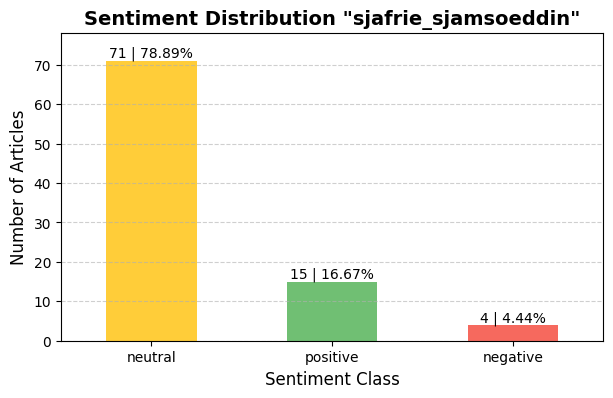

In [41]:
# DISTRIBUSI SENTIMEN BARCHART
import matplotlib.pyplot as plt

# Mapping warna per label
color_map = {
    "negative": "#F44336",
    "neutral": "#FFC107",
    "positive": "#4CAF50"
}

sentiment_counts = df["sentiment"].value_counts()

# Ambil warna sesuai urutan index-nya
colors = [color_map[label] for label in sentiment_counts.index]

plt.figure(figsize=(7,4))
bars = sentiment_counts.plot(
    kind="bar",
    color=colors,
    alpha=0.8
)

for i, v in enumerate(sentiment_counts):
    pct = (v / len(df['sentiment'])) * 100
    plt.text(i, v, f"{v} | {pct:.2f}%", ha="center", va="bottom", fontsize=10)

plt.title(f"Sentiment Distribution \"{project_name}\"", fontsize=14, fontweight="bold")
plt.xlabel("Sentiment Class", fontsize=12)
plt.ylabel("Number of Articles", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, max(sentiment_counts) * 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.savefig(f"{output_folder}/{project_name}_barchart_sentiment.png", dpi=300, bbox_inches="tight")

plt.show()

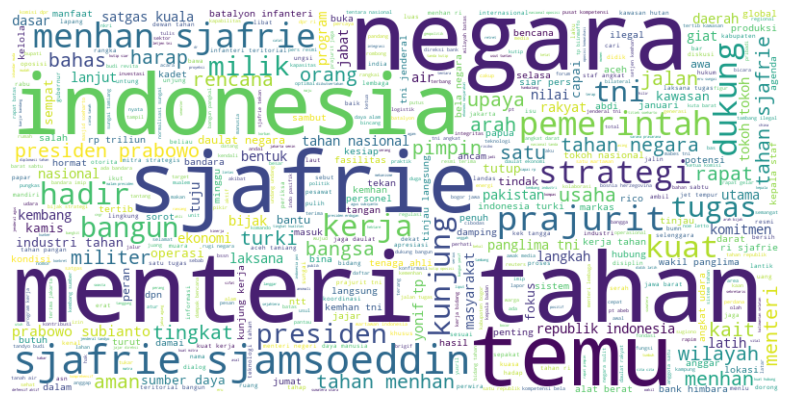

In [42]:
# WORDCLOUD 
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

sw = set(STOPWORDS)
sw.update(
    [
        'iya','lu','lo','loh','kah','ku','tau','nih','gue','dll','kak','wkwk','doang','kalo'
    ]
)

text = ' '.join(df['stemming'].astype(str).tolist())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    contour_width=1,
    contour_color='steelblue',
    colormap='viridis',
    stopwords=sw,
    max_words=800,
    random_state=42,
).generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()

# ======== Save Figure ========
plt.savefig(f"{output_folder}/{project_name}_wordcloud.png", dpi=300, bbox_inches="tight")

plt.show()

In [43]:
# WORDCLOUD DATA
import pandas as pd
from collections import Counter
from wordcloud import STOPWORDS

# base + custom stopwords
sw = set(STOPWORDS)
sw.update([
    'iya','lu','lo','loh','kah','ku','tau','nih','gue','dll','kak','wkwk','doang', 'kalo'
])

# split frasa → word → filter
words = []
for phrase in df['stemming'].astype(str):
    for w in phrase.split():
        w = w.strip()
        if w and w not in sw:
            words.append(w)

# hitung frekuensi
counter = Counter(words)
top_500 = counter.most_common(500)  # [(word, freq), ...]

# ubah urutan kolom → weight dulu, baru word
df_out = pd.DataFrame(
    [(freq, word) for word, freq in top_500],
    columns=['weight', 'word']
)

df_out.to_csv(f'{output_folder}/{project_name}_wordcloud_data.csv', index=False)

print(f"{project_name}_wordcloud_data.csv berhasil dibuat.")


sjafrie_sjamsoeddin_wordcloud_data.csv berhasil dibuat.


In [44]:
# SIMPAN HASIL
df.to_csv(f"{output_folder}/prep_{file_name}", index=False, encoding="utf-8")

# SPLIT DATA BY TANGGAL

### Cek Ideal Timeframe

In [ ]:
import os
import pandas as pd

project_name = "mbg"
file_name = "prep_mbg-tweets.csv"

# Setup folder
base_folder = f"../../result/{project_name}/tweets/preprocessing"
os.makedirs(base_folder, exist_ok=True)

# Load data
data = pd.read_csv(
    f"{base_folder}/{file_name}",
    parse_dates=['tanggal']   # kolom tanggal
)

# Pastikan kolom tanggal sudah datetime
data['tanggal'] = pd.to_datetime(data['tanggal'])

# hitung jumlah tweet per hari
daily = data.groupby('tanggal').size().reset_index(name='count')
daily = daily.sort_values('tanggal').reset_index(drop=True)

# cari peak
peak_row = daily.loc[daily['count'].idxmax()]
peak_date = peak_row['tanggal']
peak_idx = daily.index[daily['tanggal'] == peak_date][0]

# tentukan window (jumlah hari sebelum dan sesudah peak_date)
window = 7

# === CARI RISE STARTS ===
rise_date = None
start_idx = max(0, peak_idx - window)

for i in range(start_idx, peak_idx - 2):
    # cek pola naik 2 hari berturut-turut
    if (daily.loc[i+1, 'count'] > daily.loc[i, 'count'] and
        daily.loc[i+2, 'count'] > daily.loc[i+1, 'count']):
        rise_date = daily.loc[i, 'tanggal']
        break

# === CARI FALL STARTS === 
after = daily[daily['tanggal'] > peak_date].copy()
after = after.reset_index(drop=True)

fall_date = None
turning_date = None

for i in range(1, len(after)):
    prev = after.loc[i-1, 'count']
    curr = after.loc[i, 'count']

    # deteksi mulai turun
    if fall_date is None and curr < prev:
        fall_date = after.loc[i, 'tanggal']

    # setelah turun, hentikan saat naik lagi
    if fall_date is not None and curr > prev:
        turning_date = after.loc[i, 'tanggal']
        break

print("Peak date:", peak_date.date())
print("Rise starts:", rise_date.date() if rise_date is not None else None)
print("Fall starts:", fall_date.date() if fall_date else None)
print("Fall ends (turning):", turning_date.date() if turning_date else None)
print("=" * 60)
print(f"IDEAL TIMEFRAME = | since: {rise_date.date()} | until: {turning_date.date()} |")
print("=" * 60)

### Split Data

In [ ]:
# Input tanggal
since = "2025-09-21"
until = "2025-10-01"

# Filter data berdasarkan rentang tanggal
mask = (data['tanggal'] >= since) & (data['tanggal'] <= until)
filtered = data.loc[mask]

# Save ke CSV
output_path = f"{base_folder}/{project_name}_{since}_{until}_tweets.csv"
filtered.to_csv(output_path, index=False)

print("Saved:", output_path)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(output_path)

# ======== FIX FORMAT TANGGAL ========
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")

# Ambil rentang otomatis
start_date = df["tanggal"].min().date()
end_date = df["tanggal"].max().date()
df_filtered = df[(df["tanggal"].dt.date >= start_date) & (df["tanggal"].dt.date <= end_date)]

# Hitung jumlah tweet per tanggal
daily_counts = df_filtered.groupby("tanggal").size().sort_index()

# Hitung durasi total hari
total_days = (daily_counts.index.max() - daily_counts.index.min()).days

# Plot
plt.figure(figsize=(12,6))
plt.plot(daily_counts.index, daily_counts, color="#0D47A1", linewidth=2)

# ======== Format X-axis adaptif ========
ax = plt.gca()

if total_days < 14:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
elif total_days < 31:
    week_labels = []
    current_month = None
    week_counter = 1
    last_label_date = None
    for date in daily_counts.index:
        if current_month != date.strftime("%b"):
            current_month = date.strftime("%b")
            week_counter = 1
        if last_label_date is None or (date - last_label_date).days >= 7:
            week_labels.append(f"{current_month} W{week_counter}")
            week_counter += 1
            last_label_date = date
        else:
            week_labels.append("")
    plt.xticks(daily_counts.index, week_labels, rotation=45, ha="center")
else:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

# ======== Temukan puncak data ========
max_value = daily_counts.max()
max_dates = daily_counts[daily_counts == max_value].index

if len(max_dates) > 1:
    start_peak = max_dates.min()
    end_peak = max_dates.max()
    label_text = f"{max_value:,} Tweets ({start_peak.strftime('%d %B')} – {end_peak.strftime('%d %B')})"
    peak_date = start_peak + (end_peak - start_peak) / 2
else:
    peak_date = max_dates[0]
    label_text = f"{max_value:,} Tweets ({peak_date.strftime('%d %B %Y')})"

# ======== Atur batas atas Y agar label tidak keluar ========
y_margin = max_value * 0.15
plt.ylim(0, max_value + y_margin)

# ======== Tambahkan label di dalam frame ========
plt.text(
    peak_date, max_value - (y_margin * 0.3),
    label_text,
    ha="center", va="top",
    fontsize=10, color="white",
    bbox=dict(facecolor="#0D47A1", alpha=0.8, boxstyle="round,pad=0.3")
)

# ======== Styling ========
plt.title(f"Trend Tweet ({start_date.strftime('%d %B')} – {end_date.strftime('%d %B %Y')})", fontsize=14, fontweight="bold")
plt.xlabel("Dates", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

# ======== Save Figure ========
plt.savefig(f"{base_folder}/trend_tweet_{since}_{until}.png", dpi=300, bbox_inches="tight")

plt.show()
